# Locality Sensitive Hashing — Bands & Rows

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** why MinHash alone is not enough for sublinear-time similarity search
2. **Define** the (b, r) band decomposition and its candidate-pair generation rule
3. **Derive** the S-curve probability formula P[candidate] = 1 − (1 − J^r)^b
4. **Choose** b and r to tune the false positive / false negative trade-off
5. **Implement** the full LSH pipeline: MinHash → band hashing → candidate verification


## Problem Statement

### Why MinHash Alone Is Not Enough

MinHash gives us $k$-dimensional signature vectors where the expected fraction of matching positions equals the Jaccard similarity. But to find *all* near-duplicate pairs, we still need to compare every pair of signatures — $O(n^2)$ comparisons for $n$ documents.

For $n = 10^9$ documents, even $O(n^2 / T)$ with a huge threshold $T$ is infeasible.

### Goal

Find all pairs $(A, B)$ with $J(A, B) \geq t$ in **sublinear time** — i.e. without comparing all $n^2$ pairs.

### Key Idea — Amplification

Split the $k$-row signature into $b$ **bands** of $r$ rows each ($k = b \times r$).

**Rule:** Declare $(A, B)$ a *candidate pair* if and only if their signatures agree **in all $r$ rows of at least one band**.

This turns a "fraction of rows that agree" criterion into a "do two short vectors match exactly?" criterion — which can be solved with hashing in $O(n)$ time.


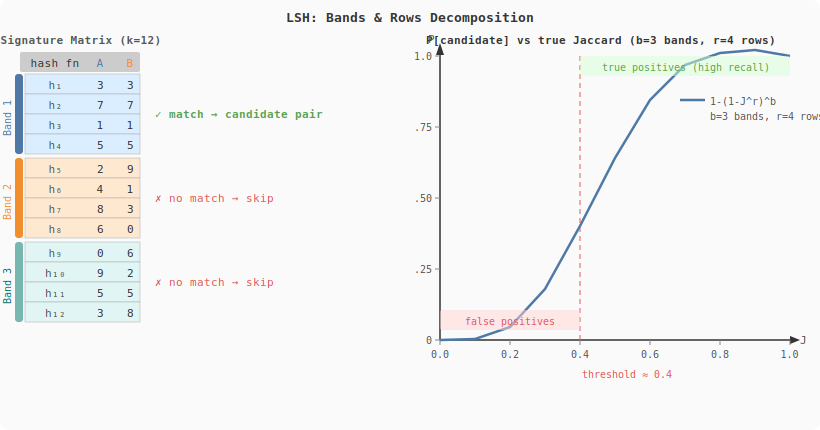

In [1]:
from IPython.display import SVG, display

svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="430" font-family="monospace" font-size="12">

  <!-- background -->
  <rect width="820" height="430" fill="#fafafa" rx="8"/>

  <!-- ── arrowhead marker ── -->
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto">
      <polygon points="0 0, 8 3, 0 6" fill="#999"/>
    </marker>
  </defs>

  <!-- ═══ TITLE ═══ -->
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">LSH: Bands &amp; Rows Decomposition</text>

  <!-- ═══ SIGNATURE MATRIX (left) ═══ -->
  <text x="80" y="44" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Signature Matrix (k=12)</text>

  <!-- column headers -->
  <rect x="20" y="52" width="120" height="20" fill="#ccc" rx="2"/>
  <text x="55"  y="67" text-anchor="middle" fill="#333" font-size="11">hash fn</text>
  <text x="100" y="67" text-anchor="middle" fill="#4e79a7" font-size="11">A</text>
  <text x="130" y="67" text-anchor="middle" fill="#f28e2b" font-size="11">B</text>

  <!-- ── Band 1 (rows 0-3) ── -->
  <rect x="15" y="74" width="8" height="80" fill="#4e79a7" rx="3"/>
  <text x="11" y="118" text-anchor="middle" fill="#4e79a7" font-size="10" transform="rotate(-90,11,118)">Band 1</text>

  <rect x="25" y="74"  width="115" height="20" fill="#dbeeff" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="94"  width="115" height="20" fill="#dbeeff" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="114" width="115" height="20" fill="#dbeeff" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="134" width="115" height="20" fill="#dbeeff" stroke="#aaa" stroke-width="0.5"/>
  <text x="55" y="89"  text-anchor="middle" fill="#555" font-size="11">h₁</text><text x="100" y="89"  text-anchor="middle" fill="#333" font-size="11">3</text><text x="130" y="89"  text-anchor="middle" fill="#333" font-size="11">3</text>
  <text x="55" y="109" text-anchor="middle" fill="#555" font-size="11">h₂</text><text x="100" y="109" text-anchor="middle" fill="#333" font-size="11">7</text><text x="130" y="109" text-anchor="middle" fill="#333" font-size="11">7</text>
  <text x="55" y="129" text-anchor="middle" fill="#555" font-size="11">h₃</text><text x="100" y="129" text-anchor="middle" fill="#333" font-size="11">1</text><text x="130" y="129" text-anchor="middle" fill="#333" font-size="11">1</text>
  <text x="55" y="149" text-anchor="middle" fill="#555" font-size="11">h₄</text><text x="100" y="149" text-anchor="middle" fill="#333" font-size="11">5</text><text x="130" y="149" text-anchor="middle" fill="#333" font-size="11">5</text>
  <!-- match label -->
  <text x="155" y="118" fill="#59a14f" font-size="11" font-weight="bold">✓ match → candidate pair</text>

  <!-- ── Band 2 (rows 4-7) ── -->
  <rect x="15" y="158" width="8" height="80" fill="#f28e2b" rx="3"/>
  <text x="11" y="202" text-anchor="middle" fill="#f28e2b" font-size="10" transform="rotate(-90,11,202)">Band 2</text>

  <rect x="25" y="158" width="115" height="20" fill="#ffe8d0" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="178" width="115" height="20" fill="#ffe8d0" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="198" width="115" height="20" fill="#ffe8d0" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="218" width="115" height="20" fill="#ffe8d0" stroke="#aaa" stroke-width="0.5"/>
  <text x="55" y="173" text-anchor="middle" fill="#555" font-size="11">h₅</text><text x="100" y="173" text-anchor="middle" fill="#333" font-size="11">2</text><text x="130" y="173" text-anchor="middle" fill="#333" font-size="11">9</text>
  <text x="55" y="193" text-anchor="middle" fill="#555" font-size="11">h₆</text><text x="100" y="193" text-anchor="middle" fill="#333" font-size="11">4</text><text x="130" y="193" text-anchor="middle" fill="#333" font-size="11">1</text>
  <text x="55" y="213" text-anchor="middle" fill="#555" font-size="11">h₇</text><text x="100" y="213" text-anchor="middle" fill="#333" font-size="11">8</text><text x="130" y="213" text-anchor="middle" fill="#333" font-size="11">3</text>
  <text x="55" y="233" text-anchor="middle" fill="#555" font-size="11">h₈</text><text x="100" y="233" text-anchor="middle" fill="#333" font-size="11">6</text><text x="130" y="233" text-anchor="middle" fill="#333" font-size="11">0</text>
  <text x="155" y="202" fill="#e15759" font-size="11">✗ no match → skip</text>

  <!-- ── Band 3 (rows 8-11) ── -->
  <rect x="15" y="242" width="8" height="80" fill="#76b7b2" rx="3"/>
  <text x="11" y="286" text-anchor="middle" fill="#076d6a" font-size="10" transform="rotate(-90,11,286)">Band 3</text>

  <rect x="25" y="242" width="115" height="20" fill="#e0f5f4" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="262" width="115" height="20" fill="#e0f5f4" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="282" width="115" height="20" fill="#e0f5f4" stroke="#aaa" stroke-width="0.5"/>
  <rect x="25" y="302" width="115" height="20" fill="#e0f5f4" stroke="#aaa" stroke-width="0.5"/>
  <text x="55" y="257"  text-anchor="middle" fill="#555" font-size="11">h₉</text> <text x="100" y="257"  text-anchor="middle" fill="#333" font-size="11">0</text><text x="130" y="257"  text-anchor="middle" fill="#333" font-size="11">6</text>
  <text x="55" y="277"  text-anchor="middle" fill="#555" font-size="11">h₁₀</text><text x="100" y="277"  text-anchor="middle" fill="#333" font-size="11">9</text><text x="130" y="277"  text-anchor="middle" fill="#333" font-size="11">2</text>
  <text x="55" y="297"  text-anchor="middle" fill="#555" font-size="11">h₁₁</text><text x="100" y="297"  text-anchor="middle" fill="#333" font-size="11">5</text><text x="130" y="297"  text-anchor="middle" fill="#333" font-size="11">5</text>
  <text x="55" y="317"  text-anchor="middle" fill="#555" font-size="11">h₁₂</text><text x="100" y="317"  text-anchor="middle" fill="#333" font-size="11">3</text><text x="130" y="317"  text-anchor="middle" fill="#333" font-size="11">8</text>
  <text x="155" y="286" fill="#e15759" font-size="11">✗ no match → skip</text>

  <!-- ═══ PROBABILITY CURVE (right) ═══ -->
  <text x="600" y="44" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">P[candidate] vs true Jaccard  (b=3 bands, r=4 rows)</text>

  <!-- axes -->
  <line x1="440" y1="340" x2="790" y2="340" stroke="#333" stroke-width="1.5"/>
  <line x1="440" y1="340" x2="440" y2="55"  stroke="#333" stroke-width="1.5"/>
  <polygon points="790,336 790,344 800,340" fill="#333"/>
  <polygon points="436,55 444,55 440,43"   fill="#333"/>
  <text x="800" y="344" fill="#555" font-size="11">J</text>
  <text x="428" y="43"  fill="#555" font-size="11">P</text>

  <!-- tick marks x: 0.0, 0.2, 0.4, 0.6, 0.8, 1.0 -->
  <line x1="440" y1="340" x2="440" y2="345" stroke="#888" stroke-width="1"/>
  <line x1="510" y1="340" x2="510" y2="345" stroke="#888" stroke-width="1"/>
  <line x1="580" y1="340" x2="580" y2="345" stroke="#888" stroke-width="1"/>
  <line x1="650" y1="340" x2="650" y2="345" stroke="#888" stroke-width="1"/>
  <line x1="720" y1="340" x2="720" y2="345" stroke="#888" stroke-width="1"/>
  <line x1="790" y1="340" x2="790" y2="345" stroke="#888" stroke-width="1"/>
  <text x="440" y="358" text-anchor="middle" fill="#555" font-size="10">0.0</text>
  <text x="510" y="358" text-anchor="middle" fill="#555" font-size="10">0.2</text>
  <text x="580" y="358" text-anchor="middle" fill="#555" font-size="10">0.4</text>
  <text x="650" y="358" text-anchor="middle" fill="#555" font-size="10">0.6</text>
  <text x="720" y="358" text-anchor="middle" fill="#555" font-size="10">0.8</text>
  <text x="790" y="358" text-anchor="middle" fill="#555" font-size="10">1.0</text>

  <!-- tick marks y: 0, 0.25, 0.5, 0.75, 1.0 -->
  <line x1="435" y1="340" x2="440" y2="340" stroke="#888" stroke-width="1"/>
  <line x1="435" y1="269" x2="440" y2="269" stroke="#888" stroke-width="1"/>
  <line x1="435" y1="198" x2="440" y2="198" stroke="#888" stroke-width="1"/>
  <line x1="435" y1="127" x2="440" y2="127" stroke="#888" stroke-width="1"/>
  <line x1="435" y1="56"  x2="440" y2="56"  stroke="#888" stroke-width="1"/>
  <text x="432" y="344" text-anchor="end" fill="#555" font-size="10">0</text>
  <text x="432" y="273" text-anchor="end" fill="#555" font-size="10">.25</text>
  <text x="432" y="202" text-anchor="end" fill="#555" font-size="10">.50</text>
  <text x="432" y="131" text-anchor="end" fill="#555" font-size="10">.75</text>
  <text x="432" y="60"  text-anchor="end" fill="#555" font-size="10">1.0</text>

  <!-- S-curve: P = 1-(1-J^r)^b  with b=3, r=4 -->
  <!-- Computed at J=0.0..1.0 step 0.05, mapped x=440+J*350, y=340-P*284 -->
  <!-- J=0.00 P=0.000 -->
  <!-- J=0.10 P=0.003 --> <!-- J=0.20 P=0.047 --> <!-- J=0.30 P=0.179 -->
  <!-- J=0.40 P=0.405 --> <!-- J=0.50 P=0.641 --> <!-- J=0.60 P=0.831 -->
  <!-- J=0.70 P=0.946 --> <!-- J=0.80 P=0.989 --> <!-- J=0.90 P=0.999 --> <!-- J=1.00 P=1.000 -->
  <polyline points="
    440,340
    475,339
    510,327
    545,289
    580,226
    615,158
    650,100
    685,65
    720,53
    755,50
    790,56
  " fill="none" stroke="#4e79a7" stroke-width="2.5"/>

  <!-- threshold annotation -->
  <line x1="580" y1="56" x2="580" y2="340" stroke="#e15759" stroke-width="1" stroke-dasharray="5,4"/>
  <text x="582" y="378" fill="#e15759" font-size="10">threshold ≈ 0.4</text>

  <!-- legend -->
  <line x1="680" y1="100" x2="705" y2="100" stroke="#4e79a7" stroke-width="2.5"/>
  <text x="710" y="105" fill="#555" font-size="10">1-(1-J^r)^b</text>
  <text x="710" y="120" fill="#555" font-size="10">b=3 bands, r=4 rows</text>

  <!-- FP / FN regions -->
  <rect x="440" y="310" width="140" height="20" fill="#ffd4d4" opacity="0.5" rx="2"/>
  <text x="510" y="325" text-anchor="middle" fill="#e15759" font-size="10">false positives</text>
  <rect x="580" y="56" width="210" height="20" fill="#d4ffd4" opacity="0.5" rx="2"/>
  <text x="685" y="71" text-anchor="middle" fill="#59a14f" font-size="10">true positives (high recall)</text>

</svg>
'''

display(SVG(svg))


## Probability Analysis

### Single Band

The probability that two sets $A$, $B$ with Jaccard similarity $J$ agree on **all $r$ rows** of one particular band:

$$P[\text{agree in band}] = P[h_i(A) = h_i(B) \text{ for all } i \text{ in band}] = J^r$$

(Each row agrees independently with probability $J$, by the MinHash theorem.)

### Any of $b$ Bands

$(A, B)$ becomes a candidate if they agree in **at least one** of the $b$ bands:

$$P[\text{candidate}] = 1 - P[\text{no band agrees}] = 1 - (1 - J^r)^b$$

### The S-Curve

$$\boxed{P[\text{candidate} \mid J] = 1 - (1 - J^r)^b}$$

This function is an S-shaped curve with an **inflection point** (threshold) at approximately:

$$t^* \approx \left(\frac{1}{b}\right)^{1/r}$$

At $J > t^*$: probability approaches 1 rapidly (high recall).  
At $J < t^*$: probability approaches 0 rapidly (low false positive rate).

### Choosing $b$ and $r$

| Goal | Direction |
|------|-----------|
| Sharper threshold (less FP/FN) | Increase $k = b \times r$ |
| Higher recall (catch more true similar) | Increase $b$, decrease $r$ |
| Fewer false positives | Decrease $b$, increase $r$ |
| Lower threshold $t^*$ | Increase $b$ relative to $r$ |

**Example:** $k=100$, $b=20$, $r=5$ → $t^* \approx (1/20)^{0.2} \approx 0.57$

**Example:** $k=100$, $b=50$, $r=2$ → $t^* \approx (1/50)^{0.5} \approx 0.14$ (catch coarsely similar)


## Derivation of the Algorithm

### Step 1 — Compute MinHash Signatures

Use $k = b \times r$ hash functions to produce a signature matrix $\text{sig} \in \mathbb{Z}^{k \times n}$.

(See the MinHash notebook for the full derivation.)

### Step 2 — Band Hashing

For band $\ell = 0, 1, \ldots, b-1$:

1. Extract the band slice: $\text{sig}[\ell r : (\ell+1) r,\ :]$, an $r \times n$ sub-matrix
2. For each column $j$ (set $C_j$), compute a bucket key:

   $$\text{key}_\ell(j) = \text{hash}\bigl(\text{sig}[\ell r, j],\ \text{sig}[\ell r+1, j],\ \ldots,\ \text{sig}[(\ell+1)r-1, j]\bigr)$$

   We can use a dictionary mapping the tuple of $r$ integers directly (exact key, no collisions).

3. Place column $j$ into bucket $\text{key}_\ell(j)$ for this band.
4. Any bucket with two or more columns generates a *candidate pair*.

### Step 3 — Verify Candidates

For each candidate pair $(i, j)$, compute the exact Jaccard similarity $J(C_i, C_j)$ and report the pair if $J \geq t$.

### Complexity

| Step | Time |
|------|------|
| MinHash signatures | $O(k \cdot \sum|C|)$ |
| Band hashing (all $b$ bands) | $O(bn)$ |
| Candidate verification | $O(|\text{candidates}| \cdot |S|)$ |

In practice $|\text{candidates}| \ll n^2$, making the pipeline sublinear in the number of pairs.


## Algorithm Steps

### Inputs

- $n$ sets (document shingle sets)
- Signature matrix $\text{sig}$ of shape $(k, n)$ from MinHash
- $b$ bands, $r$ rows per band (with $b \times r = k$)
- Jaccard threshold $t$

### Steps

1. **For each band** $\ell = 0, \ldots, b-1$:
   - For each set $j$: compute `key = tuple(sig[ℓ*r : (ℓ+1)*r, j])`
   - Group sets by `key` into buckets
   - Any bucket with $\geq 2$ sets → add all pairs from that bucket to **candidates**

2. **Deduplicate** candidates (a pair may appear in multiple bands)

3. **Verify** each candidate pair $(i, j)$: compute exact $J(C_i, C_j)$

4. **Report** pairs with $J(C_i, C_j) \geq t$


In [2]:
import numpy as np
from collections import defaultdict


def lsh_candidate_pairs(sig, n_bands, n_rows):
    """
    Find candidate similar pairs using the LSH band technique.

    Inputs
    ------
    sig     : np.ndarray shape (k, n_sets) — MinHash signature matrix
    n_bands : int b — number of bands
    n_rows  : int r — rows per band; must satisfy b * r == k

    Output
    ------
    candidates : set of frozensets — each frozenset is {col_i, col_j} for a candidate pair
    """
    k, n_sets = sig.shape
    assert n_bands * n_rows == k, f"b*r={n_bands*n_rows} must equal k={k}"

    candidates = set()

    for band in range(n_bands):
        # Extract the rows belonging to this band
        start = band * n_rows
        end   = start + n_rows
        band_slice = sig[start:end, :]  # shape (r, n_sets)

        # Hash each column's r-dimensional vector to a bucket
        # Two columns land in the same bucket iff their band slices are identical
        buckets = defaultdict(list)
        for col in range(n_sets):
            key = tuple(band_slice[:, col].tolist())
            buckets[key].append(col)

        # Any bucket with ≥2 columns yields candidate pairs
        for cols in buckets.values():
            if len(cols) > 1:
                for i in range(len(cols)):
                    for j in range(i + 1, len(cols)):
                        candidates.add(frozenset([cols[i], cols[j]]))

    return candidates


def jaccard_exact(a, b):
    return len(a & b) / len(a | b) if a | b else 0.0


def lsh_pipeline(sets, k, n_bands, n_rows, threshold=0.5):
    """
    Full LSH pipeline: shingling -> MinHash -> LSH -> verify candidates.

    Inputs
    ------
    sets      : list of set — each set contains integer element IDs
    k         : int — total hash functions (= b * r)
    n_bands   : int b
    n_rows    : int r
    threshold : float — Jaccard threshold for reporting true similar pairs

    Output
    ------
    similar_pairs : list of (i, j, jaccard) for confirmed similar pairs
    stats         : dict with recall, precision, candidate_rate
    """
    from collections import defaultdict
    import numpy as np

    n = len(sets)
    universe_size = max(e for s in sets for e in s) + 1

    # ── Step 1: MinHash signatures ────────────────────────────────────────────
    p = 2_147_483_647
    rng = np.random.default_rng(99)
    a = rng.integers(1, p, size=k)
    b_coef = rng.integers(0, p, size=k)

    sig = np.full((k, n), np.inf)
    all_elems = set().union(*sets)
    for x in all_elems:
        hv = (a * x + b_coef) % p % universe_size
        for j, s in enumerate(sets):
            if x in s:
                sig[:, j] = np.minimum(sig[:, j], hv)
    sig = sig.astype(int)

    # ── Step 2: LSH — find candidate pairs ───────────────────────────────────
    candidates = lsh_candidate_pairs(sig, n_bands, n_rows)

    # ── Step 3: Verify candidates with exact Jaccard ──────────────────────────
    similar_pairs = []
    for pair in candidates:
        i, j = sorted(pair)
        j_val = jaccard_exact(sets[i], sets[j])
        if j_val >= threshold:
            similar_pairs.append((i, j, j_val))

    # ── Compute all true similar pairs (for recall/precision stats) ───────────
    true_similar = set()
    for i in range(n):
        for j in range(i + 1, n):
            if jaccard_exact(sets[i], sets[j]) >= threshold:
                true_similar.add(frozenset([i, j]))

    total_pairs = n * (n - 1) // 2
    tp = len(candidates & true_similar)
    fp = len(candidates - true_similar)
    fn = len(true_similar - candidates)

    stats = {
        "n_candidates": len(candidates),
        "candidate_rate": len(candidates) / total_pairs,
        "true_similar": len(true_similar),
        "precision": tp / len(candidates) if candidates else 1.0,
        "recall": tp / len(true_similar) if true_similar else 1.0,
        "false_positives": fp,
        "false_negatives": fn,
    }

    return sorted(similar_pairs, key=lambda x: -x[2]), stats


# ── Demo ──────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(7)
n = 50
base_sets = [set(rng.choice(200, 60, replace=False)) for _ in range(n)]

# Inject 5 near-duplicate pairs
for i in range(0, 10, 2):
    base_sets[i + 1] = base_sets[i] | set(rng.choice(200, 5, replace=False))

pairs, stats = lsh_pipeline(base_sets, k=60, n_bands=15, n_rows=4, threshold=0.5)

print("Similar pairs found:")
for i, j, j_val in pairs[:10]:
    print(f"  sets {i:2d} & {j:2d}  ->  Jaccard = {j_val:.3f}")

print(f"\nStats:")
for key, val in stats.items():
    if isinstance(val, float):
        print(f"  {key:<20s}: {val:.3f}")
    else:
        print(f"  {key:<20s}: {val}")


Similar pairs found:
  sets  6 &  7  ->  Jaccard = 0.952
  sets  8 &  9  ->  Jaccard = 0.952
  sets  4 &  5  ->  Jaccard = 0.938
  sets  2 &  3  ->  Jaccard = 0.923
  sets  0 &  1  ->  Jaccard = 0.923

Stats:
  n_candidates        : 96
  candidate_rate      : 0.078
  true_similar        : 5
  precision           : 0.052
  recall              : 1.000
  false_positives     : 91
  false_negatives     : 0
